# From scratch: AdaBoost as sequential reweighting

This notebook implements the AdaBoost.M1 loop by hand — no `sklearn.ensemble.AdaBoostClassifier`
— to make the mechanism in `notes.md` concrete: train a weak learner, compute its weighted error
$\epsilon_t$ and vote weight $\alpha_t$, up-weight the points it got wrong, renormalize, repeat.
We use `sklearn.tree.DecisionTreeClassifier(max_depth=1)` ("stumps") as the weak learner — the point
here is demonstrating the *boosting* mechanism (reweighting + weighted voting), not re-deriving tree
splitting (already covered from scratch in `10-decision-tree`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline
rng = np.random.RandomState(1)

## 1) Toy 2D dataset

A `make_moons` toy binary-classification set. AdaBoost uses $\pm1$ labels (not $0/1$), so we remap
$y=0 \to -1$.

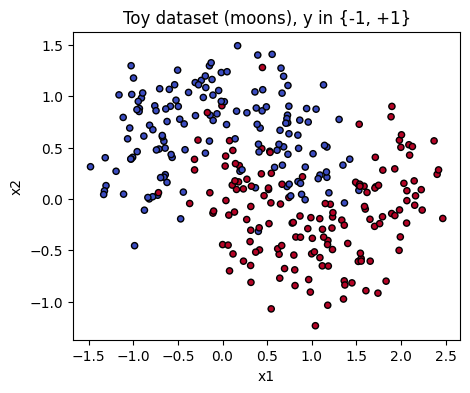

In [2]:
X, y01 = make_moons(n_samples=300, noise=0.3, random_state=1)
y = np.where(y01 == 1, 1, -1)  # AdaBoost's +/-1 encoding

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=20)
plt.title("Toy dataset (moons), y in {-1, +1}")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## 2) The manual AdaBoost loop

Implements the algorithm from `notes.md`'s Algorithm section exactly:

1. Initialize weights uniformly: $w_i^{(1)} = 1/N$.
2. For each round $t$: fit a depth-1 stump using `sample_weight=w`, compute weighted error
   $\epsilon_t = \sum_i w_i \cdot \mathbb{1}[h_t(x_i) \neq y_i]$, compute
   $\alpha_t = \frac12\ln\frac{1-\epsilon_t}{\epsilon_t}$, update
   $w_i \leftarrow w_i \cdot e^{-\alpha_t y_i h_t(x_i)}$, then renormalize so weights sum to 1.
3. Track the ensemble's training error after every round using
   $F_t(x) = \text{sign}\left(\sum_{s \le t} \alpha_s h_s(x)\right)$.

In [3]:
def adaboost_fit(X, y, n_rounds, rng):
    N = len(y)
    w = np.full(N, 1.0 / N)          # step 1: uniform initial weights
    stumps, alphas = [], []
    train_errors = []                # ensemble training error after each round
    ensemble_score = np.zeros(N)     # running sum_s alpha_s * h_s(x_i), for training points

    for t in range(n_rounds):
        stump = DecisionTreeClassifier(max_depth=1, random_state=rng.randint(1_000_000))
        stump.fit(X, y, sample_weight=w)                     # weighted weak-learner fit
        pred = stump.predict(X)

        incorrect = (pred != y)
        eps = np.sum(w[incorrect])                            # weighted error epsilon_t
        eps = np.clip(eps, 1e-10, 1 - 1e-10)                   # avoid log(0) / div-by-0
        alpha = 0.5 * np.log((1 - eps) / eps)                  # alpha_t

        w = w * np.exp(-alpha * y * pred)                      # step 3: reweight
        w = w / w.sum()                                        # step 4: renormalize

        stumps.append(stump)
        alphas.append(alpha)

        ensemble_score += alpha * pred
        train_pred = np.sign(ensemble_score)
        train_pred[train_pred == 0] = 1
        train_errors.append(np.mean(train_pred != y))

    return stumps, np.array(alphas), np.array(train_errors)


def adaboost_predict(stumps, alphas, X):
    score = np.zeros(len(X))
    for stump, alpha in zip(stumps, alphas):
        score += alpha * stump.predict(X)
    out = np.sign(score)
    out[out == 0] = 1
    return out


n_rounds = 50
stumps, alphas, train_errors = adaboost_fit(X, y, n_rounds, np.random.RandomState(0))
print(f"Final training error after {n_rounds} rounds: {train_errors[-1]:.4f}")
print(f"First 5 alphas: {np.round(alphas[:5], 3)}")

Final training error after 50 rounds: 0.1033
First 5 alphas: [0.714 0.5   0.633 0.22  0.468]


## 3) Training error vs number of boosting rounds

Each individual stump is a weak learner (barely better than 50% accuracy on the *weighted* data it
sees), but the weighted-vote ensemble's training error should drop steadily as rounds accumulate —
this is the direct, measured demonstration of "many weak learners combined sequentially become one
strong learner." See `notes.md`'s Experiment section for hypothesis/interpretation.

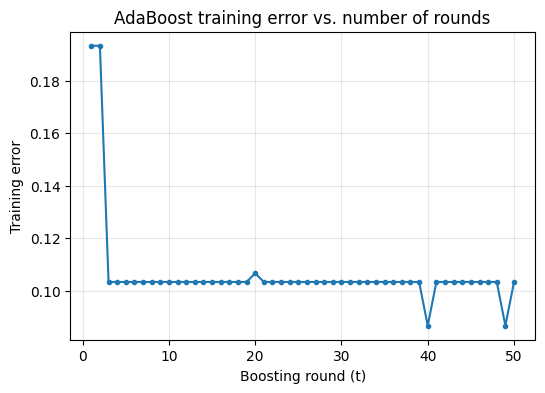

Training error after round 1:  0.1933
Training error after round 5:  0.1033
Training error after round 10: 0.1033
Training error after round 50: 0.1033


In [4]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, n_rounds + 1), train_errors, marker="o", markersize=3)
plt.xlabel("Boosting round (t)")
plt.ylabel("Training error")
plt.title("AdaBoost training error vs. number of rounds")
plt.grid(alpha=0.3)
plt.show()

print(f"Training error after round 1:  {train_errors[0]:.4f}")
print(f"Training error after round 5:  {train_errors[4]:.4f}")
print(f"Training error after round 10: {train_errors[9]:.4f}")
print(f"Training error after round 50: {train_errors[-1]:.4f}")

**Interpretation:** training error drops sharply over the first several rounds as the ensemble
picks up the dominant structure of the moons boundary, then plateaus (rather than continuing toward
zero) once the remaining errors are concentrated on points near the overlapping region of the two
moons, where noise (`noise=0.3`) makes some points genuinely ambiguous even for the full ensemble —
no stump-based ensemble can perfectly separate points that overlap in feature space. This is a
useful, honest result: "training error decreases with more rounds" does not mean "training error
goes to zero" once the weak learner's hypothesis class (axis-aligned stumps) and the data's inherent
noise impose a floor.